# Spectral Envelope Estimation — single-frame view

Visualize how the WORLD baseline's spectral envelope (`sp`, computed by CheapTrick) relates to the input signal's power spectrum on a single frame. The input contains harmonic peaks plus broadband noise; the envelope should trace the smooth spectral shape passing through (or just under) the harmonic peaks.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent.parent.parent
SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

import numpy as np
import matplotlib.pyplot as plt

from baseline import Baseline
from utils import load_audio, clip_audio, normalize_audio

/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/pyworld/__init__.py:13: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2026-04-13 11:43:27.169403: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-13 11:43:27.249085: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDN

In [2]:
# Edit this path to whichever signal you want to analyze.
audio_path = PROJECT_ROOT / 'data' / 'raw' / 'solo_violin' / 'VIII. Double.wav'

sample_rate = 16000
audio, _ = load_audio(audio_path, sr=sample_rate, mono=True)
audio = clip_audio(audio, end_time=6.0, sr=sample_rate)
audio = normalize_audio(audio).astype('float64', copy=False)

baseline = Baseline(sample_rate=sample_rate)
f0, sp, ap = baseline.decompose(audio) if hasattr(baseline, 'decompose') else (
    baseline._estimate_f0(audio, use_crepe=False),
    *baseline._compute_sp_ap(audio, baseline._estimate_f0(audio, use_crepe=False)),
)
print(f'f0   shape: {f0.shape}')
print(f'sp   shape: {sp.shape}   (n_frames, fft_size//2 + 1)')
print(f'ap   shape: {ap.shape}')

/u/37/thieun1/unix/anaconda3/envs/conda_env3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


f0   shape: (1201,)
sp   shape: (1201, 513)   (n_frames, fft_size//2 + 1)
ap   shape: (1201, 513)


In [3]:
# Pick a clearly-voiced frame (middle of the longest voiced run).
voiced = f0 > 0
voiced_idx = np.where(voiced)[0]
frame_idx = int(voiced_idx[len(voiced_idx) // 2])

frame_period_s = baseline._FRAME_PERIOD_MS / 1000.0
frame_time_s   = frame_idx * frame_period_s
f0_i           = float(f0[frame_idx])
print(f'frame {frame_idx}  |  t = {frame_time_s:.3f} s  |  f0 = {f0_i:.2f} Hz')

frame 767  |  t = 3.835 s  |  f0 = 759.76 Hz


In [4]:
# Compute a windowed power spectrum of the input centered on the chosen frame,
# using the same FFT size as WORLD's spectral envelope so the two are directly comparable.
fft_size = (sp.shape[1] - 1) * 2
half     = fft_size // 2

center = int(round(frame_time_s * sample_rate))
start  = center - half
end    = start + fft_size

pad_left  = max(0, -start)
pad_right = max(0, end - len(audio))
seg = np.pad(audio[max(0, start): min(len(audio), end)], (pad_left, pad_right))

window = np.hanning(fft_size)
X      = np.fft.rfft(seg * window)
power  = np.abs(X) ** 2
freqs  = np.fft.rfftfreq(fft_size, d=1.0 / sample_rate)
env    = sp[frame_idx]   # WORLD sp is a power spectrum (linear)

## Power spectrum vs. estimated envelope

- **Gray:** windowed FFT power spectrum of the raw input — sharp harmonic peaks at integer multiples of `f0` sitting on a noise floor.
- **Solid line:** WORLD's spectral envelope `sp[frame]`, the smooth shape CheapTrick estimates by interpolating across the harmonic comb.
- **Dashed verticals:** harmonic frequencies (`k·f0`) for reference.

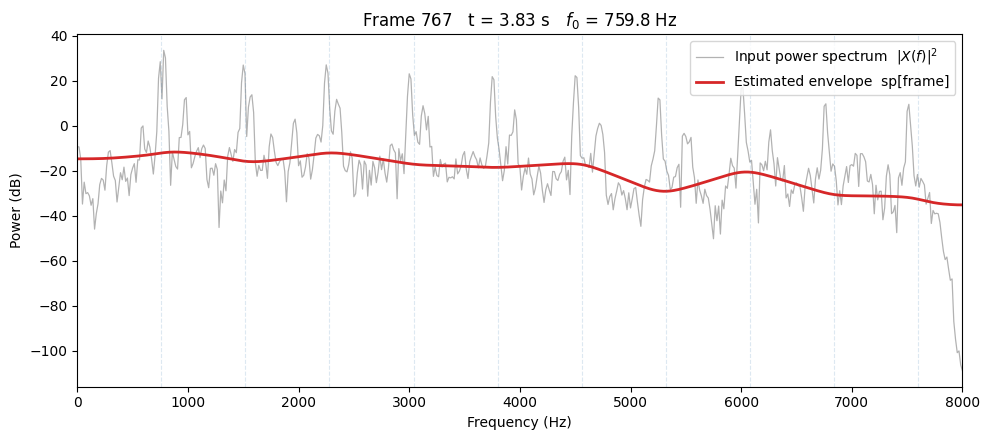

In [5]:
eps = 1e-12
power_db = 10 * np.log10(power + eps)
env_db   = 10 * np.log10(env   + eps)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(freqs, power_db, color='gray', alpha=0.6, linewidth=0.9,
        label='Input power spectrum  $|X(f)|^2$')
ax.plot(freqs, env_db,   color='C3',   linewidth=2.0,
        label='Estimated envelope  sp[frame]')

n_harm = int((sample_rate / 2) / f0_i)
for k in range(1, n_harm + 1):
    ax.axvline(k * f0_i, color='steelblue', alpha=0.18, linestyle='--', linewidth=0.8)

ax.set_xlim(0, sample_rate / 2)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB)')
ax.set_title(f'Frame {frame_idx}   t = {frame_time_s:.2f} s   $f_0$ = {f0_i:.1f} Hz')
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

### Same plot on a log-frequency axis
Useful for seeing how the envelope behaves across the lower partials, where the harmonic comb is densest.

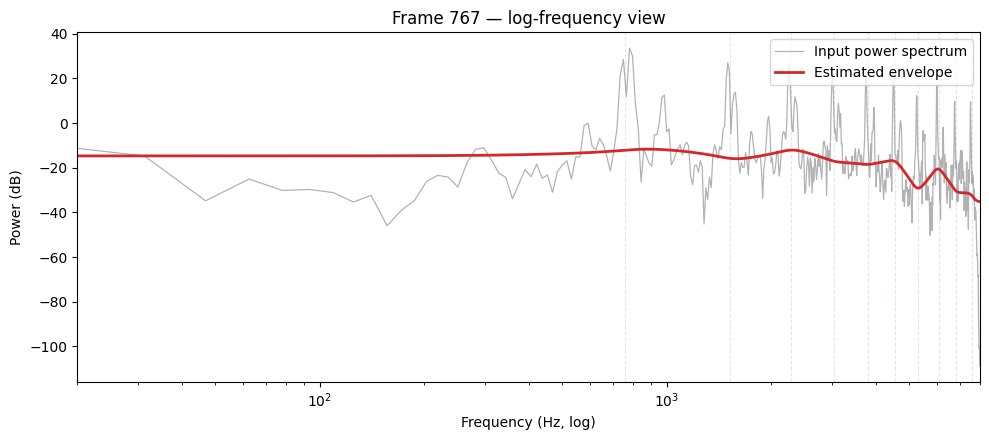

In [6]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.semilogx(freqs[1:], power_db[1:], color='gray', alpha=0.6, linewidth=0.9,
            label='Input power spectrum')
ax.semilogx(freqs[1:], env_db[1:],   color='C3',   linewidth=2.0,
            label='Estimated envelope')
for k in range(1, n_harm + 1):
    ax.axvline(k * f0_i, color='steelblue', alpha=0.18, linestyle='--', linewidth=0.8)

ax.set_xlim(20, sample_rate / 2)
ax.set_xlabel('Frequency (Hz, log)')
ax.set_ylabel('Power (dB)')
ax.set_title(f'Frame {frame_idx} — log-frequency view')
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

### A few neighbouring frames for context
Same overlay at four frames spaced through the voiced region — the envelope tracks the underlying timbre while the harmonic comb shifts with `f0`.

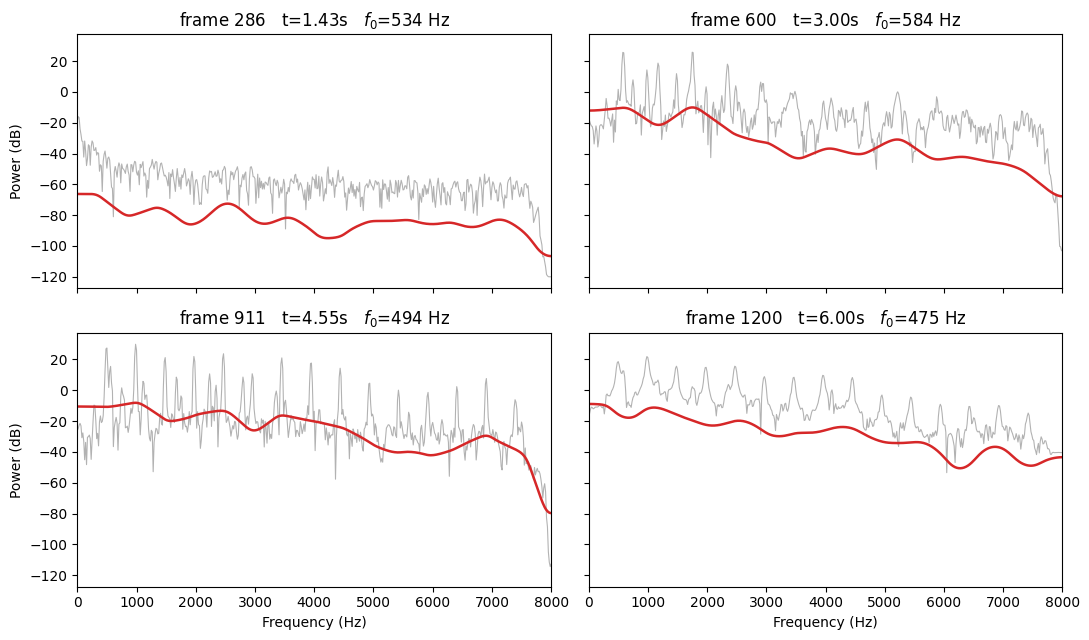

In [7]:
def power_spec_at(frame_i):
    c = int(round(frame_i * frame_period_s * sample_rate))
    s = c - half
    e = s + fft_size
    pl = max(0, -s); pr = max(0, e - len(audio))
    seg = np.pad(audio[max(0, s): min(len(audio), e)], (pl, pr))
    return np.abs(np.fft.rfft(seg * window)) ** 2

picks = np.linspace(0, len(voiced_idx) - 1, 4).astype(int)
frame_picks = voiced_idx[picks]

fig, axes = plt.subplots(2, 2, figsize=(11, 6.5), sharex=True, sharey=True)
for ax, fi in zip(axes.ravel(), frame_picks):
    p_db = 10 * np.log10(power_spec_at(fi) + eps)
    e_db = 10 * np.log10(sp[fi] + eps)
    ax.plot(freqs, p_db, color='gray', alpha=0.6, linewidth=0.8)
    ax.plot(freqs, e_db, color='C3',   linewidth=1.8)
    ax.set_title(f'frame {int(fi)}   t={fi*frame_period_s:.2f}s   $f_0$={f0[fi]:.0f} Hz')
    ax.set_xlim(0, sample_rate / 2)
for ax in axes[-1, :]: ax.set_xlabel('Frequency (Hz)')
for ax in axes[:, 0]: ax.set_ylabel('Power (dB)')
fig.tight_layout()
plt.show()